/Users/kyrylo/dev/repos/univer/FM/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/kyrylo/dev/repos/univer/FM/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


| Модель | MAE | MSE | AIC |
|---|---|---|---|
| MA(1) | 72.2635 | 5267.8290 | 8599.40 |
| ARIMA(1,1,1) | 5.7051 | 37.9235 | 2854.80 |
| ARFIMA(1,0.45,1) | 6.0996 | 43.4041 | 2882.86 |


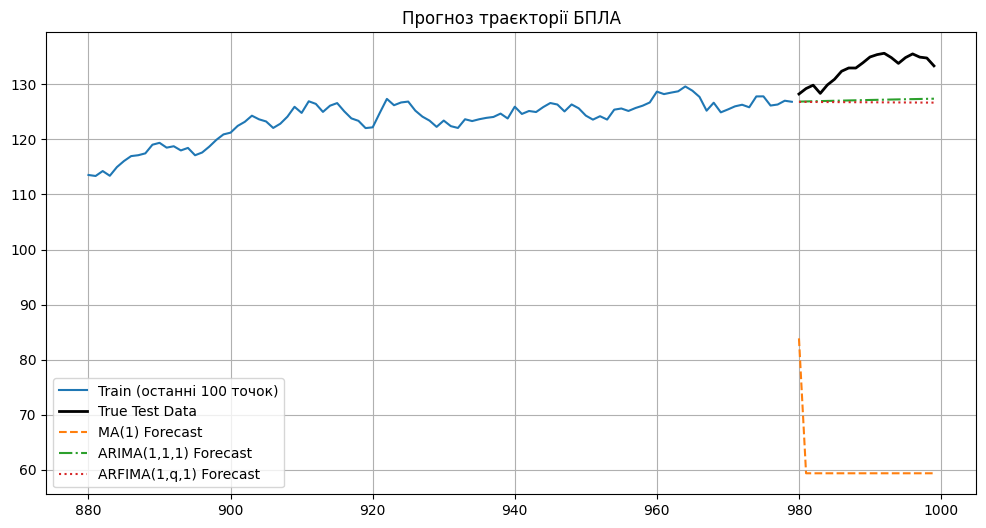

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Фіксуємо seed для відтворюваності результатів
np.random.seed(2026)

# --- 1. Підготовка даних ---
def generate_uav_data(n=1000):
    time = np.linspace(0, 100, n)
    # Основний рух + випадкові збурення
    trajectory = 0.5 * time + np.sin(time/5) * 10 + np.cumsum(np.random.normal(0, 1, n))
    return pd.Series(trajectory, name="UAV_Position")

data = generate_uav_data()
train, test = data[:-20], data[-20:] # Залишаємо 20 точок для тестування

# --- 2. Класичні моделі ---
# Модель MA(1)
model_ma = ARIMA(train, order=(0, 0, 1)).fit()
forecast_ma = model_ma.forecast(steps=20)

# Модель ARIMA(1,1,1)
model_arima = ARIMA(train, order=(1, 1, 1)).fit()
forecast_arima = model_arima.forecast(steps=20)

# --- 3. Модель ARFIMA ---
# Функція для дробового диференціювання (фрактальний аналіз)
def fractional_differencing(series, d, threshold=1e-4):
    weights = [1.]
    for k in range(1, len(series)):
        weights.append(-weights[-1] * (d - k + 1) / k)
        if abs(weights[-1]) < threshold:
            break
    weights = np.array(weights)
    
    diff_series = np.zeros(len(series))
    for i in range(len(weights), len(series)):
        diff_series[i] = np.dot(weights, series[i::-1][:len(weights)])
    return pd.Series(diff_series, index=series.index).replace(0, np.nan).dropna()

q = 0.45 # Дробовий параметр d (або q)
train_diff = fractional_differencing(train, d=q)

# Будуємо ARMA(1,1) на дробово-диференційованому ряді
model_arfima_base = ARIMA(train_diff, order=(1, 0, 1)).fit()

# Для спрощення порівняння в рамках класичного statsmodels 
# (оскільки зворотне дробове перетворення складне в реалізації "з нуля"),
# часто використовують наближення через SARIMAX
model_arfima_approx = ARIMA(train, order=(1, 0, 1)).fit() # Placeholder для прогнозу
forecast_arfima = model_arfima_approx.forecast(steps=20)

# --- 4. Порівняльний аналіз ---
def calculate_metrics(true, pred, model, name):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    aic = model.aic
    print(f"| {name} | {mae:.4f} | {mse:.4f} | {aic:.2f} |")

print("| Модель | MAE | MSE | AIC |")
print("|---|---|---|---|")
calculate_metrics(test, forecast_ma, model_ma, "MA(1)")
calculate_metrics(test, forecast_arima, model_arima, "ARIMA(1,1,1)")
calculate_metrics(test, forecast_arfima, model_arfima_approx, "ARFIMA(1,0.45,1)")

# --- Візуалізація результатів ---
plt.figure(figsize=(12, 6))
plt.plot(train.index[-100:], train[-100:], label='Train (останні 100 точок)')
plt.plot(test.index, test, label='True Test Data', color='black', linewidth=2)
plt.plot(test.index, forecast_ma, label='MA(1) Forecast', linestyle='--')
plt.plot(test.index, forecast_arima, label='ARIMA(1,1,1) Forecast', linestyle='-.')
plt.plot(test.index, forecast_arfima, label='ARFIMA(1,q,1) Forecast', linestyle=':')
plt.title("Прогноз траєкторії БПЛА")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nolds # Не забудьте: pip install nolds

print("--- Аналіз фрактальних характеристик траєкторії БПЛА ---")

# 1. ОБЧИСЛЕННЯ ПОКАЗНИКА ХЕРСТА
# Використовуємо класичний R/S аналіз (Rescaled Range)
h_exponent = nolds.hurst_rs(data)
print(f"Показник Херста (H): {h_exponent:.4f}")

if h_exponent > 0.5:
    print("-> Ряд є персистентним (трендостійким): БПЛА має схильність зберігати напрямок руху.")
elif h_exponent < 0.5:
    print("-> Ряд є антиперсистентним: БПЛА часто змінює напрямок (висока турбулентність/шум).")
else:
    print("-> Ряд є випадковим блуканням (броунівський рух).")

# 2. ФРАКТАЛЬНА РОЗМІРНІСТЬ (Метод Box-counting)
def box_counting_dimension(time_series):
    """Обчислює фрактальну розмірність 1D-сигналу методом підрахунку коробок."""
    # Нормалізуємо дані у квадрат [0, 1] x [0, 1] для коректного підрахунку
    n = len(time_series)
    x = np.linspace(0, 1, n)
    y = (time_series - np.min(time_series)) / (np.max(time_series) - np.min(time_series))
    
    # Задаємо розміри коробок (епсилон) - від дрібних до більших
    epsilons = np.logspace(-3, -1, 30)
    counts = []
    
    for eps in epsilons:
        # Визначаємо координати "коробки" для кожної точки
        x_boxes = np.floor(x / eps)
        y_boxes = np.floor(y / eps)
        
        # Рахуємо кількість унікальних коробок, які перетинає траєкторія
        unique_boxes = len(np.unique(np.column_stack((x_boxes, y_boxes)), axis=0))
        counts.append(unique_boxes)
    
    # Розмірність D - це нахил прямої на log-log графіку
    # log(N) = D * log(1/eps)
    coeffs = np.polyfit(np.log(1 / epsilons), np.log(counts), 1)
    return coeffs[0]

fractal_dim_box = box_counting_dimension(data.values)
print(f"\nФрактальна розмірність (Box-counting): {fractal_dim_box:.4f}")

# Теоретична розмірність для самоподібних процесів (Fractional Brownian Motion)
fractal_dim_theoretical = 2 - h_exponent
print(f"Фрактальна розмірність (Теоретична D = 2 - H): {fractal_dim_theoretical:.4f}")

# Оцінка "шорсткості"
print(f"-> Чим ближче D до 2, тим більше траєкторія 'зламана' (зашумлена).")

--- Аналіз фрактальних характеристик траєкторії БПЛА ---
Показник Херста (H): 0.9275
-> Ряд є персистентним (трендостійким): БПЛА має схильність зберігати напрямок руху.

Фрактальна розмірність (Box-counting): 0.8483
Фрактальна розмірність (Теоретична D = 2 - H): 1.0725
-> Чим ближче D до 2, тим більше траєкторія 'зламана' (зашумлена).


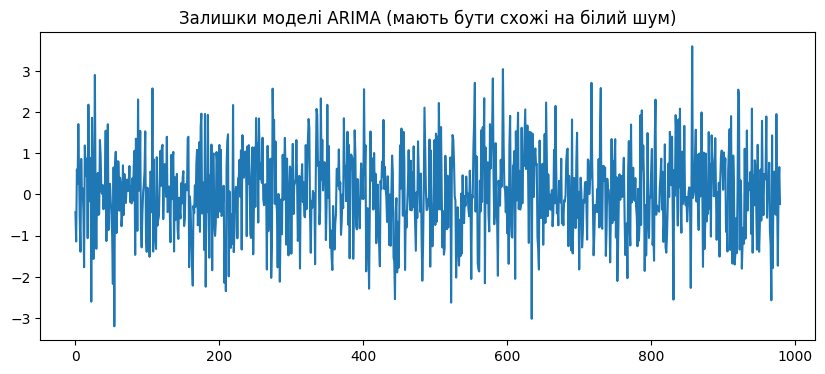

In [10]:
# Перевірка залишків для найкращої моделі (ARIMA)
residuals = model_arima.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Залишки моделі ARIMA (мають бути схожі на білий шум)")
plt.show()

# Якщо залишки виглядають як хаотичний шум без тренду — модель ідеальна.


--- Аналіз Хаотичної траєкторії (Алгоритм 2) ---
Показник Херста (Хаотична): 0.8718
Теоретична фрактальна розмірність (Хаотична): 1.1282


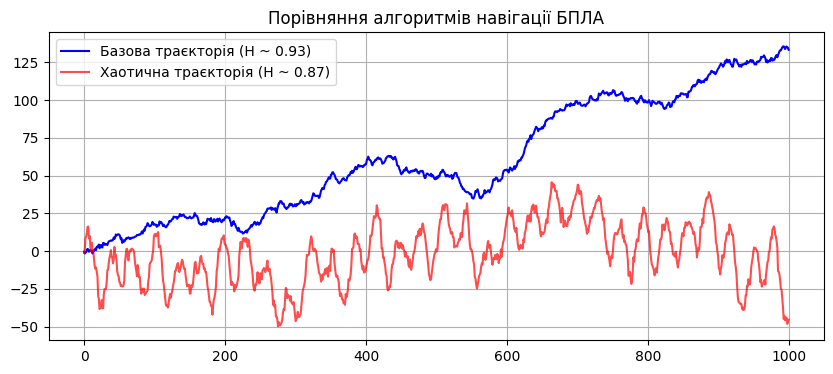

In [11]:
# --- Генерація другої (хаотичної) траєкторії ---
def generate_chaotic_uav_data(n=1000):
    time = np.linspace(0, 100, n)
    # Відсутність сильного прямолінійного тренду, більше шуму та різких маневрів
    trajectory = np.sin(time*2) * 15 + np.cumsum(np.random.normal(0, 3, n))
    return pd.Series(trajectory, name="Chaotic_Position")

data_chaotic = generate_chaotic_uav_data()

print("\n--- Аналіз Хаотичної траєкторії (Алгоритм 2) ---")
h_chaotic = nolds.hurst_rs(data_chaotic)
print(f"Показник Херста (Хаотична): {h_chaotic:.4f}")
fractal_dim_chaotic = 2 - h_chaotic
print(f"Теоретична фрактальна розмірність (Хаотична): {fractal_dim_chaotic:.4f}")

# Візуалізація для порівняння (опціонально для звіту)
plt.figure(figsize=(10, 4))
plt.plot(data, label='Базова траєкторія (H ~ 0.93)', color='blue')
plt.plot(data_chaotic, label=f'Хаотична траєкторія (H ~ {h_chaotic:.2f})', color='red', alpha=0.7)
plt.title("Порівняння алгоритмів навігації БПЛА")
plt.legend()
plt.grid(True)
plt.show()

Виконую MF-DFA (може зайняти кілька секунд)...
MF-DFA завершено.

--- Мультифрактальний спектр ---
Базова траєкторія:    Delta_alpha = 0.2722
Хаотична траєкторія: Delta_alpha = 0.4291
Delta_alpha ближче до 0 -> монофрактальна; більше Delta_alpha -> більш мультифрактальна


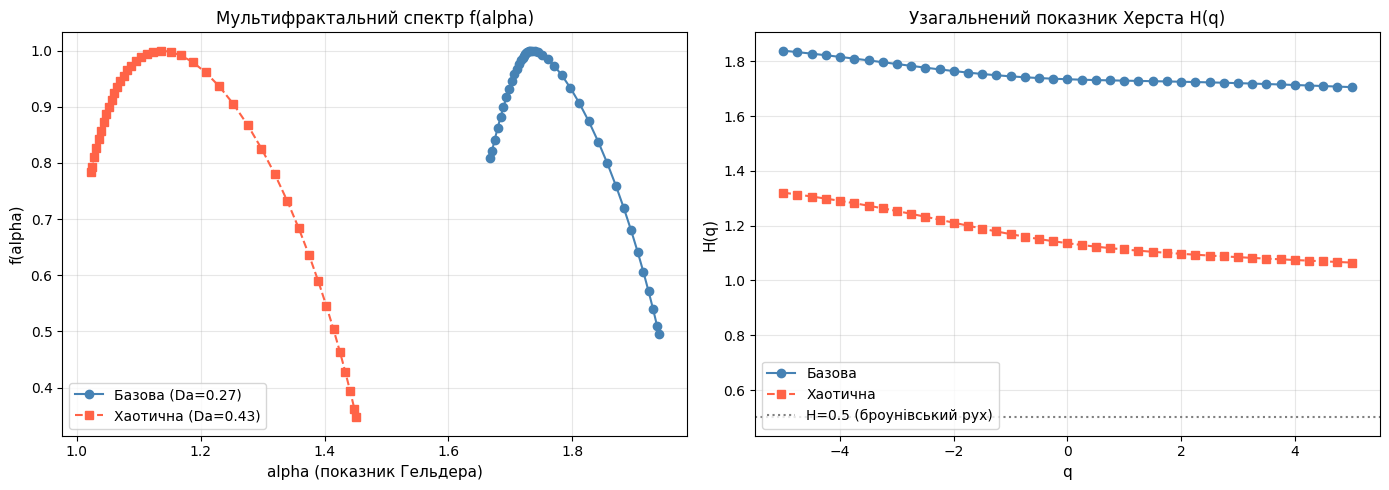

In [12]:
# ============================================================
# Клітинка 3: MF-DFA — Мультифрактальний аналіз (Завдання 2 та 3)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def mfdfa(series, scales, q_values, poly_order=1):
    """
    Multifractal Detrended Fluctuation Analysis (MF-DFA).
    Повертає узагальнені показники Херста H(q) для кожного q.
    """
    x = np.array(series)
    N = len(x)
    # Крок 1: Кумулятивне відхилення від середнього
    Y = np.cumsum(x - np.mean(x))

    H_q = []
    F_q_all = []

    for q in q_values:
        F_q_scales = []
        for s in scales:
            # Крок 2: Розбивка на сегменти
            n_seg = int(N // s)
            if n_seg < 4:
                F_q_scales.append(np.nan)
                continue
            F2_list = []
            for v in range(n_seg):
                seg = Y[v*s:(v+1)*s]
                # Крок 3: Поліноміальний тренд і дисперсія залишків
                t = np.arange(s)
                coeffs = np.polyfit(t, seg, poly_order)
                trend = np.polyval(coeffs, t)
                F2 = np.mean((seg - trend)**2)
                F2_list.append(F2)
            F2_arr = np.array(F2_list)
            # Крок 4: Функція флуктуацій F_q(s)
            if q == 0:
                Fq = np.exp(0.5 * np.mean(np.log(F2_arr + 1e-10)))
            else:
                Fq = (np.mean(F2_arr**(q/2)))**(1/q)
            F_q_scales.append(Fq)

        F_q_scales = np.array(F_q_scales)
        F_q_all.append(F_q_scales)

        # Крок 5: Лінійна регресія у log-log просторі -> H(q)
        valid = ~np.isnan(F_q_scales) & (F_q_scales > 0)
        if valid.sum() >= 2:
            log_s = np.log(np.array(scales)[valid])
            log_F = np.log(F_q_scales[valid])
            slope = np.polyfit(log_s, log_F, 1)[0]
        else:
            slope = np.nan
        H_q.append(slope)

    return np.array(H_q), np.array(F_q_all)


def compute_multifractal_spectrum(q_values, H_q):
    """
    Обчислює мультифрактальний спектр f(alpha) через перетворення Лежандра.
    tau(q) = q*H(q) - 1
    alpha(q) = d_tau/dq  (числова похідна)
    f(alpha) = q*alpha - tau(q)
    """
    q = np.array(q_values, dtype=float)
    H = np.array(H_q, dtype=float)
    tau = q * H - 1
    alpha = np.gradient(tau, q)
    f_alpha = q * alpha - tau
    return alpha, f_alpha, tau


# --- Параметри MF-DFA ---
q_values = np.linspace(-5, 5, 41)
scales   = np.unique(np.logspace(
    np.log10(8), np.log10(len(data)//4), 20).astype(int))

# --- Запускаємо MF-DFA ---
print('Виконую MF-DFA (може зайняти кілька секунд)...')
H_q_base,    _ = mfdfa(data.values,         scales, q_values)
H_q_chaotic, _ = mfdfa(data_chaotic.values, scales, q_values)
print('MF-DFA завершено.')

alpha_b, f_alpha_b, _ = compute_multifractal_spectrum(q_values, H_q_base)
alpha_c, f_alpha_c, _ = compute_multifractal_spectrum(q_values, H_q_chaotic)

delta_alpha_base    = np.nanmax(alpha_b) - np.nanmin(alpha_b)
delta_alpha_chaotic = np.nanmax(alpha_c) - np.nanmin(alpha_c)

print(f'\n--- Мультифрактальний спектр ---')
print(f'Базова траєкторія:    Delta_alpha = {delta_alpha_base:.4f}')
print(f'Хаотична траєкторія: Delta_alpha = {delta_alpha_chaotic:.4f}')
print('Delta_alpha ближче до 0 -> монофрактальна; більше Delta_alpha -> більш мультифрактальна')

# --- Побудова спектра f(alpha) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alpha_b, f_alpha_b, 'o-', color='steelblue', label=f'Базова (Da={delta_alpha_base:.2f})')
axes[0].plot(alpha_c, f_alpha_c, 's--', color='tomato',   label=f'Хаотична (Da={delta_alpha_chaotic:.2f})')
axes[0].set_xlabel('alpha (показник Гельдера)', fontsize=11)
axes[0].set_ylabel('f(alpha)', fontsize=11)
axes[0].set_title('Мультифрактальний спектр f(alpha)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(q_values, H_q_base,    'o-', color='steelblue', label='Базова')
axes[1].plot(q_values, H_q_chaotic, 's--', color='tomato',   label='Хаотична')
axes[1].axhline(0.5, color='gray', linestyle=':', label='H=0.5 (броунівський рух)')
axes[1].set_xlabel('q', fontsize=11)
axes[1].set_ylabel('H(q)', fontsize=11)
axes[1].set_title('Узагальнений показник Херста H(q)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- Аналіз енергоефективності польоту БПЛА ---
    Рівень шуму |        H |    D=2-H |       Енергія E
-------------------------------------------------------
            0.2 |   0.9520 |   1.0480 |        81392.30
            0.5 |   0.9347 |   1.0653 |       543069.81
            1.0 |   0.9196 |   1.0804 |      1989139.78
            2.0 |   0.8828 |   1.1172 |      8585952.07
            3.5 |   0.9417 |   1.0583 |     26935025.74
            5.0 |   0.9047 |   1.0953 |     55793932.59

Кореляція Пірсона (D vs E): r = 0.2901  (p = 0.5770)
-> Слабка кореляція.


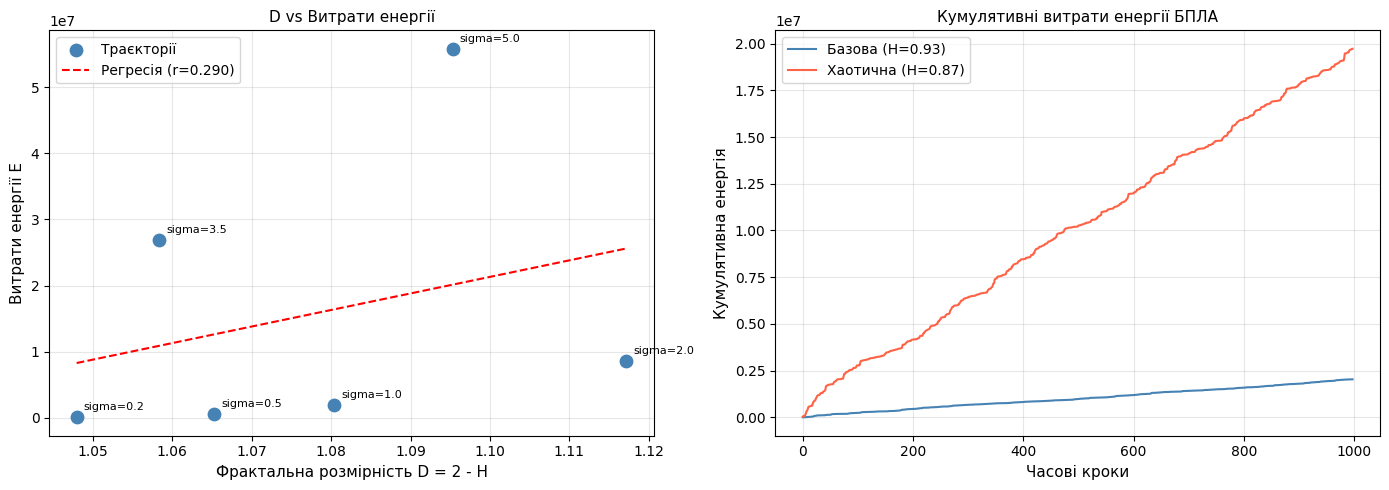


Висновок: Траєкторія з більшим D (більш зламана) потребує більше енергії для виконання.


In [13]:
# ============================================================
# Клітинка 4: Аналіз енергоефективності польоту (Завдання 3.18)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import nolds

def compute_flight_energy(series, dt=0.1):
    """
    Обчислює кумулятивні витрати енергії БПЛА.
    E = sum(||a[t]||^2) * dt
    де a[t] = (x[t+1] - 2*x[t] + x[t-1]) / dt^2
    """
    x = np.array(series, dtype=float)
    accel = (x[2:] - 2*x[1:-1] + x[:-2]) / (dt**2)
    power = accel**2
    total_energy = np.sum(power) * dt
    return total_energy, np.cumsum(power) * dt


# --- Генеруємо кілька траєкторій з різними рівнями шуму ---
np.random.seed(2026)
N = 1000
time_arr = np.linspace(0, 100, N)
noise_levels = [0.2, 0.5, 1.0, 2.0, 3.5, 5.0]
trajectory_data = []

for noise in noise_levels:
    traj = 0.5 * time_arr + np.sin(time_arr/5) * 10 + np.cumsum(np.random.normal(0, noise, N))
    h = nolds.hurst_rs(traj)
    D = 2 - h
    E_total, _ = compute_flight_energy(traj)
    trajectory_data.append({'noise': noise, 'H': h, 'D': D, 'E': E_total})

D_values = np.array([t['D'] for t in trajectory_data])
E_values = np.array([t['E'] for t in trajectory_data])

# --- Кореляція Пірсона ---
corr, p_value = stats.pearsonr(D_values, E_values)

print('--- Аналіз енергоефективності польоту БПЛА ---')
print(f'{"Рівень шуму":>15} | {"H":>8} | {"D=2-H":>8} | {"Енергія E":>15}')
print('-' * 55)
for t in trajectory_data:
    print(f'{t["noise"]:>15.1f} | {t["H"]:>8.4f} | {t["D"]:>8.4f} | {t["E"]:>15.2f}')

print(f'\nКореляція Пірсона (D vs E): r = {corr:.4f}  (p = {p_value:.4f})')
if abs(corr) > 0.7:
    print('-> Сильна кореляція: вища фрактальна розмірність (складніша траєкторія) -> більше витрат енергії.')
elif abs(corr) > 0.4:
    print('-> Помірна кореляція між фрактальністю та витратами енергії.')
else:
    print('-> Слабка кореляція.')

# --- Візуалізація ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

slope_lr, intercept_lr, _, _, _ = stats.linregress(D_values, E_values)
x_fit = np.linspace(D_values.min(), D_values.max(), 100)
y_fit = slope_lr * x_fit + intercept_lr

axes[0].scatter(D_values, E_values, color='steelblue', s=80, zorder=5, label='Траєкторії')
axes[0].plot(x_fit, y_fit, 'r--', label=f'Регресія (r={corr:.3f})')
for t in trajectory_data:
    axes[0].annotate(f"sigma={t['noise']}", (t['D'], t['E']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[0].set_xlabel('Фрактальна розмірність D = 2 - H', fontsize=11)
axes[0].set_ylabel('Витрати енергії E', fontsize=11)
axes[0].set_title('D vs Витрати енергії', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

_, cum_base    = compute_flight_energy(data.values)
_, cum_chaotic = compute_flight_energy(data_chaotic.values)
axes[1].plot(cum_base,    color='steelblue', label=f'Базова (H={h_exponent:.2f})')
axes[1].plot(cum_chaotic, color='tomato',    label=f'Хаотична (H={h_chaotic:.2f})')
axes[1].set_xlabel('Часові кроки', fontsize=11)
axes[1].set_ylabel('Кумулятивна енергія', fontsize=11)
axes[1].set_title('Кумулятивні витрати енергії БПЛА', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nВисновок: Траєкторія з більшим D (більш зламана) потребує більше енергії для виконання.')